# 🧠 Tutorial 2: Opening the Black Box - Individual-Level Interpretation

Welcome to the second tutorial for **HeteroRC**! 

While decoding accuracy from HeteroRC tells us *whether* information is present in the brain, cognitive neuroscientists and clinicians ultimately want to know *how* and *where* this information is represented. Recurrent models are often criticized as "black boxes." However, HeteroRC addresses this by pairing a fixed temporal reservoir with a transparent linear readout, enabling a direct mapping back to physiological signals.

In this tutorial, we will use real EEG data from a single participant (**Subject 01**) performing a **Motor Imagery task** (BCI Competition IV-2a dataset). We will:
1. Load the real EEG recordings.
2. Run strict cross-validation on the training set to identify the peak decoding time (preventing circular analysis).
3. Project the full dataset (Train + Test) into the reservoir to maximize the Signal-to-Noise Ratio (SNR).
4. Use the `analyze_dynamics` function to extract Haufe activation patterns, cluster the most informative reservoir units into **Virtual Sources**, and visualize their temporal (ERP), spectral (TFR/PSD), and spatial (Topomap) motifs.
5. Extract the raw internal data returned by the framework to plot the temporal dynamics of individual top-ranked reservoir nodes, demonstrating how to perform custom secondary analyses. 

In [ ]:
import os

## ---  Prevent Jupyter Kernel Crashes, if needed ---
## Limit multi-threading for underlying matrix libraries (OpenBLAS/MKL)
## This prevents thread contention during heavy operations like Haufe Transform and TFR.
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV

# Import HeteroRC modules
from heterorc import HeteroRC, time_resolved_decoding_heterorc
from heterorc_interpretation import analyze_dynamics

# --- USER CONFIGURATION ---
DATA_DIR = r"./BCI2a/Data"  # Update to your local path
SUBJECT = 1

SFREQ = 100.0  
N_RESERVOIR = 800  

bci2a_class_names = ["Left Hand", "Right Hand", "Foot", "Tongue"]

## Step 1: Data Loading & Preprocessing

*Note: This tutorial assumes you have the BCI Competition IV-2a dataset (`A01T.gdf` and `A01E.gdf/mat`) downloaded.*

We will load the training and evaluation sessions, apply a standard 10-20 montage, bandpass filter (0.5 - 30 Hz), resample to 100 Hz, and extract epochs from -0.2s to 3.2s relative to the cue onset.

In [5]:
# To keep the tutorial clean, we define a simplified data loader here.
# In practice, you might import this from a dedicated dataloader script.

def load_bci2a_subject(sub_id, data_dir, sfreq=100.0):
    """Simplified loader for BCI2a Subject (Train & Test)."""
    import scipy.io
    
    bci2a_channels = [
        "Fz", "FC3", "FC1", "FCz", "FC2", "FC4", "C5", "C3", "C1", "Cz", "C2", 
        "C4", "C6", "CP3", "CP1", "CPz", "CP2", "CP4", "P1", "Pz", "P2", "POz"
    ]
    
    def process_run(fname, is_test=False):
        raw = mne.io.read_raw_gdf(os.path.join(data_dir, fname), preload=True, verbose=False)
        raw.rename_channels(dict(zip(raw.ch_names[:22], bci2a_channels)))
        for ch in raw.ch_names[22:]: raw.set_channel_types({ch: "eog"})
        raw.set_montage(mne.channels.make_standard_montage("standard_1020"))
        
        raw.filter(0.5, 30.0, fir_design="firwin", verbose=False)
        raw.resample(sfreq, npad="auto", verbose=False)
        raw.set_eeg_reference("average", projection=False, verbose=False)
        
        event_id = {"783": 100} if is_test and "783" in raw.annotations.description else \
                   {"769": 1, "770": 2, "771": 3, "772": 4}
        events, _ = mne.events_from_annotations(raw, event_id=event_id, verbose=False)
        
        if is_test and "783" not in raw.annotations.description:
            # Shift '768' (trial start) by 2s to match cue
            events_start, _ = mne.events_from_annotations(raw, event_id={"768": 100}, verbose=False)
            events = events_start.copy()
            events[:, 0] += int(2.0 * sfreq)
            
        if is_test and len(events) > 288: events = events[-288:]
        
        epochs = mne.Epochs(raw, events, tmin=-0.2, tmax=3.2, picks="eeg", 
                            baseline=(-0.2, 0), preload=True, verbose=False)
        return epochs

    # Load Train
    ep_train = process_run(f"A0{sub_id}T.gdf", is_test=False)
    X_train, y_train = ep_train.get_data(copy=True) * 1e6, ep_train.events[:, -1]
    
    # Load Test
    ep_test = process_run(f"A0{sub_id}E.gdf", is_test=True)
    mat = scipy.io.loadmat(os.path.join(data_dir, f"A0{sub_id}E.mat"))
    y_test = np.concatenate([
        mat["data"][0][i]["y"][0, 0].flatten() if "y" in mat["data"][0][i].dtype.names 
        else mat["data"][0][i]["classlabel"][0, 0].flatten() for i in range(3, 9)
    ])
    X_test = ep_test.get_data(copy=True) * 1e6
    
    return X_train, y_train, X_test, y_test, ep_train.times, ep_train.info

# Execute loading
print("Loading data... (This may take a minute)")
try:
    X_train, y_train, X_test, y_test, times, info = load_bci2a_subject(SUBJECT, DATA_DIR, SFREQ)
    print(f"✅ Data loaded! Train: {X_train.shape}, Test: {X_test.shape}")
except Exception as e:
    print(f"❌ Failed to load data. Please ensure the dataset is in {DATA_DIR}. Error: {e}")

Loading data... (This may take a minute)


D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
D:\ANACONDA2024\envs\mne\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


✅ Data loaded! Train: (288, 22, 341), Test: (288, 22, 341)


## Step 2: Strict Cross-Validation for Peak Selection

To extract robust neurophysiological patterns, we want to analyze the reservoir dynamics at the time point where the model is most confident (i.e., peak decoding accuracy). 

**Crucial Methodological Point**: To completely prevent circular analysis (selection bias / double dipping), we must identify this peak decoding time *exclusively* using Cross-Validation on the **Training Session**. The Evaluation Session remains entirely unseen at this stage.

Computing TRAIN-CV decoding curve for peak search...
Fold 1/5 done. scale=12.5
Fold 2/5 done. scale=13
Fold 3/5 done. scale=12.9
Fold 4/5 done. scale=13
Fold 5/5 done. scale=12.9

✅ Peak decoding time identified at: 1.700 s (Accuracy: 0.368)


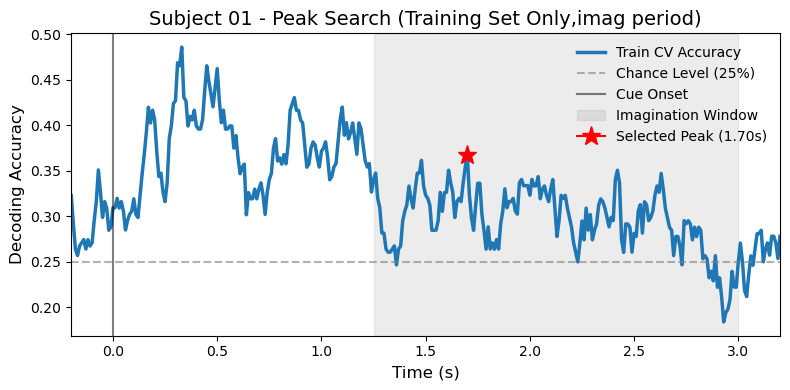

In [7]:
# HeteroRC parameters tailored for real EEG
rc_params = dict(
    n_res=N_RESERVOIR,
    input_scaling=0.5,
    bias_scaling=0.5,
    spectral_radius=0.95,
    tau_mode=0.01,
    tau_sigma=0.8,
    tau_min=0.002,
    tau_max=0.08,
    bidirectional=True,
    merge_mode="product",
)

# Temporal smoothing parameters
sigma_points = (25.0 / 1000.0 * SFREQ) / 2.355

print("Computing TRAIN-CV decoding curve for peak search...")

cv_curve = time_resolved_decoding_heterorc(
    X=X_train,
    y=y_train,
    times=times,
    n_folds=5,
    fs=SFREQ,
    rc_params=rc_params,
    scale_percentile=99,
    rc_seed_mode="fixed",               
    base_rc_random_state=42,
    metric="accuracy",
    smooth_decisions=True,
    smooth_sigma_points=sigma_points,
    verbose=True,
)

# Find peak inside the Imagination window (1.25s - 3.0s)
imagination_mask = (times >= 1.25) & (times <= 3.0)
imagination_indices = np.where(imagination_mask)[0]

peak_offset = int(np.argmax(cv_curve[imagination_indices]))
peak_idx = int(imagination_indices[peak_offset])
peak_time = float(times[peak_idx])

print(f"\n✅ Peak decoding time identified at: {peak_time:.3f} s (Accuracy: {cv_curve[peak_idx]:.3f})")

# --- Plotting the Train-CV Decoding Curve ---
plt.figure(figsize=(8, 4))
plt.plot(times, cv_curve, lw=2.5, color="#1f77b4", label="Train CV Accuracy")

# Plot references
plt.axhline(0.25, linestyle="--", color="gray", alpha=0.6, label="Chance Level (25%)")
plt.axvline(0.0, color="black", lw=1.5, alpha=0.5, label="Cue Onset")
plt.axvspan(1.25, 3.0, color="gray", alpha=0.15, label="Imagination Window")

# Highlight the selected peak
plt.plot(peak_time, cv_curve[peak_idx], marker='*', color='red', markersize=14, label=f"Selected Peak ({peak_time:.2f}s)")

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Decoding Accuracy", fontsize=12)
plt.title(f"Subject {SUBJECT:02d} - Peak Search (Training Set Only,imag period)", fontsize=14)
plt.legend(loc="upper right", frameon=False)
plt.xlim(-0.2, 3.2)
plt.tight_layout()
plt.show()

## Step 3: Full-Dataset Refitting for Interpretation

Once the peak time is independently identified, our goal shifts from *prediction* to *physiological interpretation*. 

To maximize the Signal-to-Noise Ratio (SNR) for the Haufe transform and source reconstruction, we now concatenate the Train and Evaluation sets. We apply a fixed HeteroRC reservoir and fit a Ridge readout **strictly at the pre-identified peak time**.

In [8]:
# Concatenate datasets
X_full = np.concatenate([X_train, X_test], axis=0)
y_full = np.concatenate([y_train, y_test], axis=0)

# Apply global robust scaling (99th percentile) to ensure all trials occupy the same dynamic range.
scale_val = np.percentile(np.abs(X_full), 99)
X_full_s = X_full / scale_val

# Initialize one fixed reservoir
esn = HeteroRC(
    n_in=X_full.shape[1],
    random_state=42,
    fs=SFREQ,
    **rc_params
)

print(f"Projecting full dataset into the {N_RESERVOIR}-dimensional reservoir...")
S_full = esn.transform(X_full_s)  # Shape: (n_full, n_res, n_times)

# Fit the linear readout AT THE PEAK TIME ONLY
clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=(0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0)))
clf.fit(S_full[:, :, peak_idx], y_full)

print("Linear readout successfully fitted at peak time.")

Projecting full dataset into the 400-dimensional reservoir...
Linear readout successfully fitted at peak time.


## Step 4: Latent Dynamics Interpretation

This is where the magic happens! We will pass our fitted model and reservoir states into the `analyze_dynamics` function. 

This function performs the following steps automatically:
1. **Haufe Transform**: Converts the backward readout weights into forward activation patterns, revealing which reservoir units truly drive the decision.
2. **Clustering**: Groups the top $N$ most informative units into functional clusters based on their temporal dynamics.
3. **Virtual Source Reconstruction**: Averages the units within each cluster to create latent virtual source signals.
4. **Multi-domain Visualization**:
   - **Top Row (Scatter & Dendrogram)**: Shows unit importance vs. intrinsic timescale ($f_c$).
   - **Per-Cluster Rows**: Evaluates the virtual sources across the temporal domain (ERPs), time-frequency domain (Morlet wavelets TFRs), spectral domain (PSD parameterized by FOOOF), and spatial domain (Sensor-space projection Topomaps).

Running interpretation module at 1.700s...

Running STAGE 1 (V10 - poster) | Subject 01 | Motor Imagery | peak @ 1.700s


C:\Users\Lenovo\Documents\GitHub\heterorc\heterorc_interpretation.py:316: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


-> Clustering: requested 3, got 3


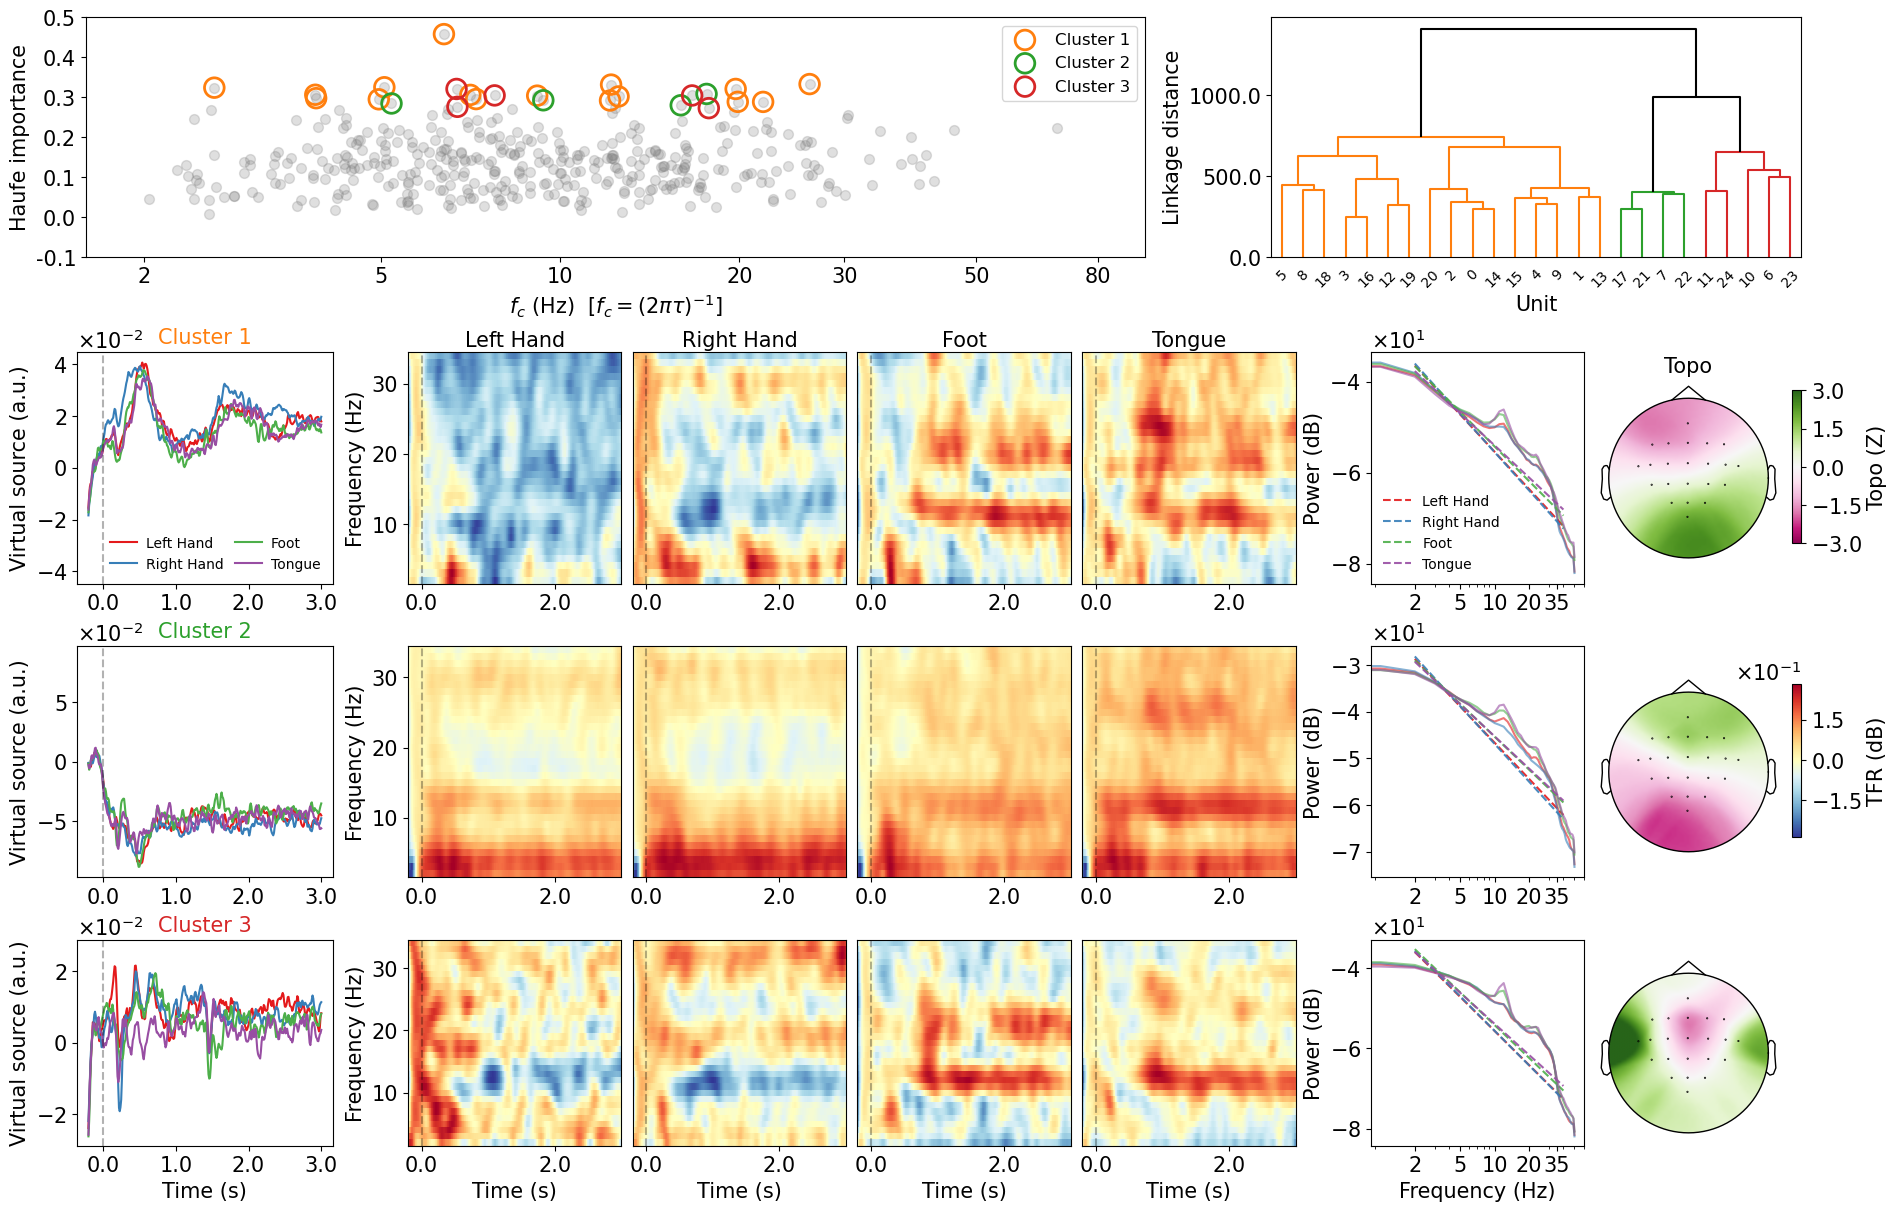

In [9]:
print(f"Running interpretation module at {peak_time:.3f}s...")

# NOTE: If you don't have the 'fooof' package installed, the PSD aperiodic fitting 
# will be gracefully skipped, but the raw PSD will still be plotted.

rc_interpretation = analyze_dynamics(
    esn=esn,
    classifier=clf,
    target_time=peak_time,
    state_snapshot=S_full,
    y_labels=y_full,
    times=times,
    n_clusters=3,
    top_n=25,
    phase_name=f"Subject {SUBJECT:02d} | Motor Imagery",
    plot_style="poster",

    # Settings for physiological domains
    erp_range=(-0.2, 3.0),
    erp_baseline_mode="mean",
    erp_baseline_range=(-0.2, 0),
    tfr_baseline_mode="logratio",
    tfr_baseline_range=(-0.2, 0.0),
    tfr_freqs=np.arange(2, 35, 1),
    fooof_params={"max_n_peaks": 4, "peak_width_limits": [1, 8]},
    figsize=(18, 12),
    class_names=bci2a_class_names, 
    
    # Required for inline sensor-space Topomaps
    inline_topomaps=True,      
    info=info,          
    raw_X_snapshot=X_full,          
    cov_window_half_width=0.1, 
    
    return_results=True
)

# You can access the raw virtual source time-series from the returned dictionary:
# s_virt_cluster_1 = rc_interpretation["clusters"]["Cluster 1"]["S_virt"]

## Step 5: Peeking Inside - Extracting Raw Reservoir Data

In many research scenarios, you may want to perform custom secondary analyses or plot the data using your own styling. By setting `return_results=True` in the `analyze_dynamics` function, HeteroRC returns a comprehensive dictionary containing all the underlying data.

The returned dictionary (`rc_interpretation`) contains:
* **`meta`**: Metadata about the analysis (e.g., sampling rate, target time).
* **`neurons`**: The Haufe importance scores and the indices of the top-ranked reservoir units.
* **`clusters`**: The raw time-series (`S_virt`), weights, and member unit indices for each reconstructed virtual source.
* **`figure`**: The matplotlib figure handle.

Let's extract the indices of the **Top 10 most informative reservoir units** and plot their trial-averaged temporal dynamics for the "Left Hand" imagery condition. This allows us to see exactly what the most critical individual "neurons" in our reservoir are doing over time.

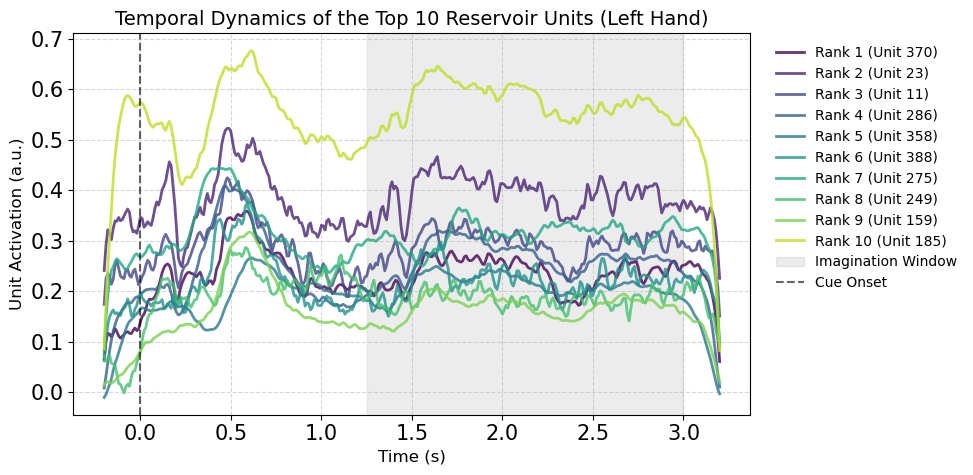

In [10]:
# 1. Extract the indices of the reservoir units sorted by Haufe importance (descending)
top_10_units = rc_interpretation["neurons"]["top_indices"][:10]

# 2. Identify the label for the first class (e.g., "Left Hand")
class_label = np.unique(y_full)[0] 
class_name = bci2a_class_names[0]

# 3. Plot the trial-averaged time series for these 10 units
plt.figure(figsize=(10, 5))

# We use a colormap to differentiate the 10 units
colors = plt.cm.viridis(np.linspace(0, 0.9, 10))

for i, unit_idx in enumerate(top_10_units):
    # Extract the raw reservoir states for this specific unit and condition
    # S_full shape: (n_trials, n_res, n_times)
    unit_activity = S_full[y_full == class_label, unit_idx, :].mean(axis=0)
    
    plt.plot(
        times, 
        unit_activity, 
        label=f"Rank {i+1} (Unit {unit_idx})", 
        color=colors[i], 
        linewidth=2, 
        alpha=0.8
    )

# Formatting the plot
plt.axvspan(1.25, 3.0, color="gray", alpha=0.15, label="Imagination Window")
plt.axvline(0, color="black", linestyle="--", alpha=0.6, label="Cue Onset")

plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Unit Activation (a.u.)", fontsize=12)
plt.title(f"Temporal Dynamics of the Top 10 Reservoir Units ({class_name})", fontsize=14)

# Place legend outside the plot
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()